<a href="https://colab.research.google.com/github/Ravikrishna234/Data-Science-new/blob/master/ANLY715_Week1_Reproducible_Workflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ANLY 715 · Week 1 Starter Notebook


**Assignment.** Submit a Colab notebook demonstrating a reproducible ML/DL workflow with fixed random seeds, preprocessing pipelines, cross-validation, hyperparameter tuning, evaluation metrics, and package/environment documentation.

**How to use this starter.**
1. `File ▸ Save a copy in Drive`, then rename it `ANLY715_Week1_<LastName>.ipynb`.
2. Run it top to bottom once as-is (`Runtime ▸ Run all`) to see the full workflow on the built-in dataset.
3. Complete every cell marked **✏️ TODO**. Cells marked **✅ keep** may be used unchanged.
4. Before submitting: `Runtime ▸ Restart and run all` must finish without errors.
5. Submit the share link (*Anyone with the link: Viewer*) in Canvas by the due date.

**Dataset.** The Wisconsin Diagnostic Breast Cancer dataset ships with scikit-learn (no download): 569 tumours, 30 numeric features computed from cell-nucleus images, and a binary label (malignant vs benign). It is small, clean, and mildly imbalanced, which makes the validation lessons visible.

| Section | Requirement covered |
|---|---|
| 1 | Fixed random seeds |
| 2–3 | Data loading and inspection |
| 4 | Split before anything else |
| 5 | Preprocessing pipeline (no leakage) |
| 6 | Cross-validation |
| 7 | Hyperparameter tuning (nested) |
| 8 | Evaluation metrics on the held-out test set |
| 9 | Deep-learning branch (Keras MLP) with the same discipline |
| 10 | Seed sweep: how stable is the result? |
| 11 | Environment documentation |
| 12 | Write-up (Methods paragraph) |

## 1. Fixed random seeds  ✅ keep
Set the seed in **every** library that draws random numbers. A seed makes the notebook reproducible; it does not make the result correct (see Section 10).

In [1]:
SEED = 42

import os, random
import numpy as np
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

# TensorFlow / Keras is used in Section 9; seed it here so the whole notebook is consistent
try:
    import tensorflow as tf
    tf.random.set_seed(SEED)
    TF_OK = True
except Exception as e:
    TF_OK = False
    print("TensorFlow not available; Section 9 will be skipped.", e)

print("Seeds fixed at", SEED)

Seeds fixed at 42


## 2. Load the built-in dataset  ✅ keep

In [3]:
import pandas as pd
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer(as_frame=True)
X = data.data.copy()            # 30 numeric features
y = data.target.copy()          # 0 = malignant, 1 = benign
target_names = list(data.target_names)

print("X shape:", X.shape, "| y shape:", y.shape)
print("classes:", dict(zip(range(2), target_names)))
print("class balance:\n", y.value_counts(normalize=True).round(3))
X.head()

X shape: (569, 30) | y shape: (569,)
classes: {0: np.str_('malignant'), 1: np.str_('benign')}
class balance:
 target
1    0.627
0    0.373
Name: proportion, dtype: float64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## 3. Inspect before modelling  ✏️ TODO
Check types, missingness, scale, and correlation. Write two sentences at the end on what you noticed (e.g. features on very different scales, highly correlated groups of features).

float64    30
Name: count, dtype: int64
missing values: 0


,mean,std,min,max
mean radius,14.13,3.52,6.98,28.11
mean texture,19.29,4.30,9.71,39.28
mean perimeter,91.97,24.30,43.79,188.50
mean area,654.89,351.91,143.50,2501.00
mean smoothness,0.10,0.01,0.05,0.16
mean compactness,0.10,0.05,0.02,0.35
mean concavity,0.09,0.08,0.00,0.43
mean concave points,0.05,0.04,0.00,0.20
mean symmetry,0.18,0.03,0.11,0.30
mean fractal dimension,0.06,0.01,0.05,0.10


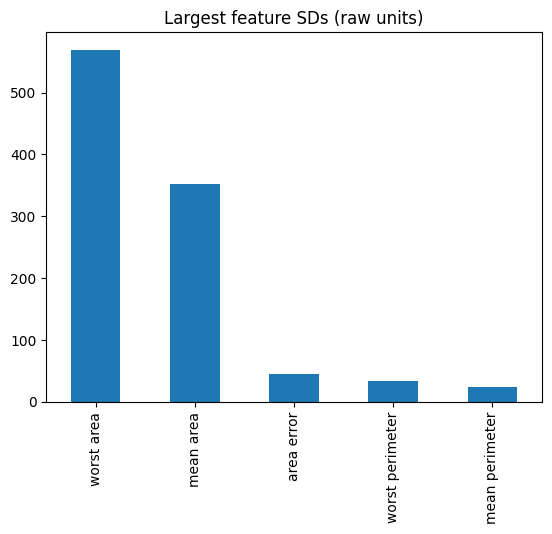

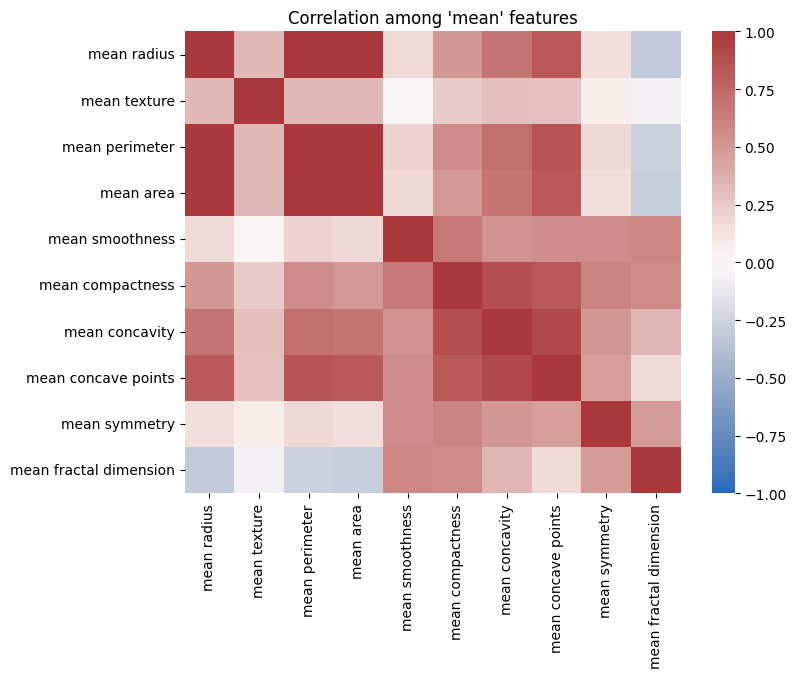

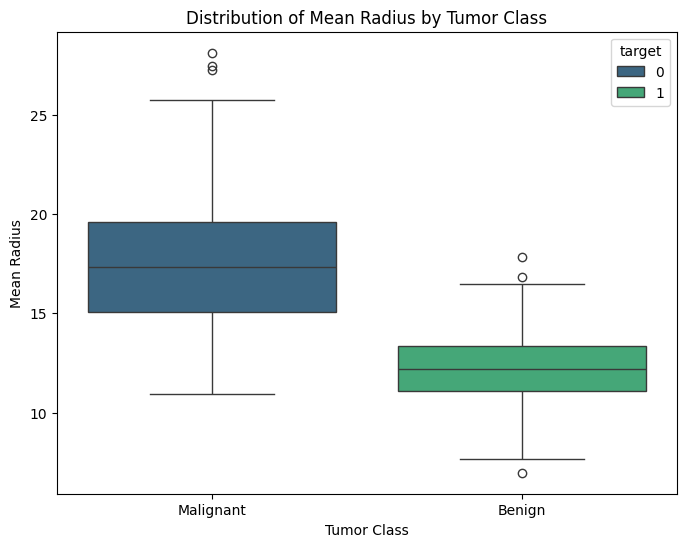

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

print(X.dtypes.value_counts())
print("missing values:", int(X.isna().sum().sum()))
display(X.describe().T[["mean", "std", "min", "max"]].round(2).head(10))

# Scale differences: why standardization will matter
X.std().sort_values(ascending=False).head(5).plot(kind="bar", title="Largest feature SDs (raw units)"); plt.show()

# Correlation structure among the 'mean' features
mean_cols = [c for c in X.columns if c.startswith("mean")]
plt.figure(figsize=(8, 6))
sns.heatmap(X[mean_cols].corr(), cmap="vlag", vmin=-1, vmax=1)
plt.title("Correlation among 'mean' features"); plt.show()

# Plot comparing a feature between the two classes (boxplot or violin)
plt.figure(figsize=(8, 6))
sns.boxplot(x=y, y=X['mean radius'], hue=y, palette='viridis')
plt.xticks(ticks=[0, 1], labels=['Malignant', 'Benign'])
plt.title('Distribution of Mean Radius by Tumor Class')
plt.xlabel('Tumor Class')
plt.ylabel('Mean Radius')
plt.show()

✏️ **TODO – observations (2 sentences):** ...

## 4. Split first  ✅ keep
Create the held-out **test** set before any preprocessing decisions. Stratify so both classes keep their proportions. The test set is touched exactly once, in Section 8.

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=SEED)

print("train:", X_train.shape, "| test:", X_test.shape)
print("train class balance:", y_train.value_counts(normalize=True).round(3).to_dict())

train: (455, 30) | test: (114, 30)
train class balance: {1: 0.626, 0: 0.374}


## 5. Preprocessing pipeline  ✏️ TODO
All preprocessing goes inside a `Pipeline` so it is **fit on training folds only** and re-applied identically to validation folds and the test set. This is what prevents leakage.

$z = \dfrac{x - \mu}{\sigma}$ where $\mu, \sigma$ are computed from training rows only.

Your task: keep the scaler, then add **one** more step of your choice and justify it in the comment (options: `PCA(n_components=...)`, `SelectKBest`, `PolynomialFeatures(degree=2)`, or `VarianceThreshold`).

In [11]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression

preprocess = Pipeline([
    ("impute", SimpleImputer(strategy="median")),   # no missing values here, but real data will have them
    ("scale", StandardScaler()),
    # ✅ TODO: add one step, e.g. ("pca", PCA(n_components=10, random_state=SEED)),
    ("pca", PCA(n_components=10, random_state=SEED)), # Added PCA to reduce dimensionality and decorrelate features.
    # Justification: PCA helps reduce the number of features while retaining most of the variance, and can mitigate issues with highly correlated features, potentially improving model performance and reducing noise.
])

# Baseline model attached to the same pipeline
baseline = Pipeline([
    ("prep", preprocess),
    ("model", LogisticRegression(max_iter=2000, random_state=SEED)),
])
baseline

Pipeline(steps=[('prep',
                 Pipeline(steps=[('impute', SimpleImputer(strategy='median')),
                                 ('scale', StandardScaler()),
                                 ('pca',
                                  PCA(n_components=10, random_state=42))])),
                ('model', LogisticRegression(max_iter=2000, random_state=42))])

## 6. Cross-validation  ✅ keep
$\mathrm{CV} = \frac{1}{k}\sum_{j=1}^{k} L(\hat f_{-j}, D_j)$ — train on $k-1$ folds, score on the held-out fold, rotate, average. Report mean **and** spread. Because the scaler is inside the pipeline, it is re-fit inside every fold automatically.

In [12]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
scoring = ["accuracy", "f1", "roc_auc", "average_precision"]

res = cross_validate(baseline, X_train, y_train, cv=cv, scoring=scoring, return_train_score=True)
summary = pd.DataFrame({m: [res[f"test_{m}"].mean(), res[f"test_{m}"].std(), res[f"train_{m}"].mean()]
                        for m in scoring}, index=["cv_mean", "cv_sd", "train_mean"]).T.round(4)
display(summary)
print("Train–CV gap on accuracy: %.4f  (large gap → overfitting)" % (summary.loc["accuracy", "train_mean"] - summary.loc["accuracy", "cv_mean"]))

,cv_mean,cv_sd,train_mean
accuracy,0.9824,0.0054,0.9885
f1,0.9861,0.0042,0.9908
roc_auc,0.9954,0.0050,0.9968
average_precision,0.9967,0.0040,0.9977


Train–CV gap on accuracy: 0.0061  (large gap → overfitting)


## 7. Hyperparameter tuning  ✏️ TODO
Tuning on the same folds you report from is optimistic. Use **nested** cross-validation: an inner `GridSearchCV` chooses hyperparameters, an outer loop estimates performance.

Compare at least **two model families**. The starter tunes logistic regression (C) and a random forest; replace or add one (e.g. `SVC`, `GradientBoostingClassifier`, `KNeighborsClassifier`).

In [13]:
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

candidates = {
    "logreg": (
        Pipeline([("prep", preprocess), ("model", LogisticRegression(max_iter=5000, random_state=SEED))]),
        {"model__C": [0.01, 0.1, 1, 10]},
    ),
    "random_forest": (
        Pipeline([("prep", preprocess), ("model", RandomForestClassifier(random_state=SEED, n_jobs=-1))]),
        {"model__n_estimators": [100, 300], "model__max_depth": [None, 4, 8]},
    ),
    # ✅ TODO: add a third family, e.g.
    "svm": (Pipeline([("prep", preprocess), ("model", SVC(probability=True, random_state=SEED))]),
            {"model__C": [0.1, 1, 10], "model__gamma": ["scale", 0.01]}),
}

inner = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
outer = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

nested_results = {}
for name, (pipe, grid) in candidates.items():
    search = GridSearchCV(pipe, grid, cv=inner, scoring="roc_auc", n_jobs=-1)
    scores = cross_val_score(search, X_train, y_train, cv=outer, scoring="roc_auc")
    nested_results[name] = scores
    print(f"{name:14s} nested CV ROC-AUC = {scores.mean():.4f} \u00b1 {scores.std():.4f}")

best_name = max(nested_results, key=lambda k: nested_results[k].mean())
print("\nSelected family:", best_name)

# Fit the final tuned model of the selected family on ALL training data
final_search = GridSearchCV(candidates[best_name][0], candidates[best_name][1], cv=outer, scoring="roc_auc", n_jobs=-1)
final_search.fit(X_train, y_train)
final_model = final_search.best_estimator_
print("Best hyperparameters:", final_search.best_params_)

logreg         nested CV ROC-AUC = 0.9948 ± 0.0047
random_forest  nested CV ROC-AUC = 0.9876 ± 0.0068
svm            nested CV ROC-AUC = 0.9961 ± 0.0050

Selected family: svm
Best hyperparameters: {'model__C': 10, 'model__gamma': 0.01}


✏️ **TODO – one paragraph:** which family did you select, and why is the nested estimate more trustworthy than `final_search.best_score_`?

## 8. Evaluate once on the held-out test set  ✅ keep
$\text{Precision} = \frac{TP}{TP+FP}$, $\text{Recall} = \frac{TP}{TP+FN}$, $F_1 = \frac{2PR}{P+R}$.
Here class 0 is **malignant**, so a false negative (calling a malignant tumour benign) is the costly error: recall for class 0 matters most. Report the metrics, the confusion matrix, ROC and precision–recall curves, and calibration.

              precision    recall  f1-score   support

   malignant      0.911     0.976     0.943        42
      benign      0.986     0.944     0.965        72

    accuracy                          0.956       114
   macro avg      0.948     0.960     0.954       114
weighted avg      0.958     0.956     0.956       114

Test ROC-AUC: 0.9960 | Brier score: 0.0257


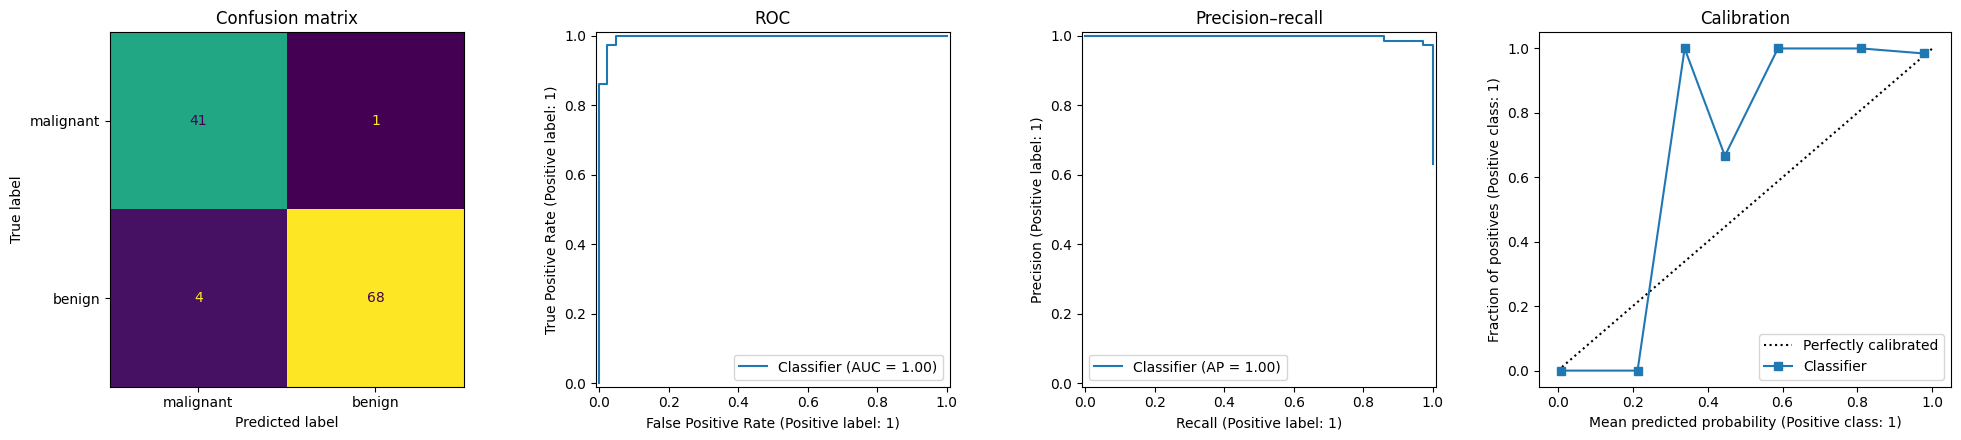

Malignant recall = 0.976  (missed malignant cases: 1 of 42)


In [15]:
from sklearn.metrics import (classification_report, confusion_matrix, ConfusionMatrixDisplay,
                             RocCurveDisplay, PrecisionRecallDisplay, roc_auc_score, brier_score_loss)
from sklearn.calibration import CalibrationDisplay

y_pred = final_model.predict(X_test)
y_prob = final_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=target_names, digits=3))
print("Test ROC-AUC: %.4f | Brier score: %.4f" % (roc_auc_score(y_test, y_prob), brier_score_loss(y_test, y_prob)))

fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred), display_labels=target_names).plot(ax=axes[0], colorbar=False); axes[0].set_title("Confusion matrix")
RocCurveDisplay.from_predictions(y_test, y_prob, ax=axes[1]); axes[1].set_title("ROC")
PrecisionRecallDisplay.from_predictions(y_test, y_prob, ax=axes[2]); axes[2].set_title("Precision–recall")
CalibrationDisplay.from_predictions(y_test, y_prob, n_bins=8, ax=axes[3]); axes[3].set_title("Calibration")
plt.tight_layout(); plt.show()

# Malignant recall (class 0) is the safety-critical number
cm = confusion_matrix(y_test, y_pred)
print("Malignant recall = %.3f  (missed malignant cases: %d of %d)" % (cm[0, 0] / cm[0].sum(), cm[0, 1], cm[0].sum()))

✅ **TODO – which single metric would you put in the abstract, and why?**

For the abstract, the single most important metric to highlight is the **malignant recall (recall for class 0)**. In the context of breast cancer classification, a false negative (misclassifying a malignant tumor as benign) is the most critical and potentially life-threatening error. High malignant recall indicates that the model is effectively identifying nearly all actual malignant cases, minimizing these dangerous false negatives. While other metrics like ROC-AUC and average precision provide a broader understanding of overall model performance, malignant recall directly addresses the safety-critical aspect of this medical diagnosis problem, making it the most impactful and relevant metric for an abstract.

## 9. Deep-learning branch: Keras MLP with the same discipline  ✏️ TODO
The rules do not change for neural networks: seed, scale on training data only, validate, tune, test once. A small MLP is wrapped so scikit-learn's cross-validation can drive it.

Your task: change **one** architectural choice (units, layers, dropout rate, learning rate) and compare the CV result to the starter's.

In [18]:
if TF_OK:
    from tensorflow import keras
    from sklearn.base import BaseEstimator, ClassifierMixin

    class KerasMLP(ClassifierMixin, BaseEstimator):
        """Minimal sklearn wrapper so Pipeline + CV work with a Keras model."""

        def __init__(
            self,
            units=32,
            dropout=0.2,
            lr=1e-3,
            epochs=60,
            seed=SEED
        ):
            self.units = units
            self.dropout = dropout
            self.lr = lr
            self.epochs = epochs
            self.seed = seed

        def _build(self, n_in):
            keras.utils.set_random_seed(self.seed)

            m = keras.Sequential([
                keras.layers.Input(shape=(n_in,)),
                keras.layers.Dense(
                    self.units,
                    activation="relu"
                ),
                keras.layers.Dropout(
                    self.dropout
                ),
                keras.layers.Dense(
                    1,
                    activation="sigmoid"
                ),
            ])

            m.compile(
                optimizer=keras.optimizers.Adam(
                    learning_rate=self.lr
                ),
                loss="binary_crossentropy"
            )

            return m

        def fit(self, X, y):
            # Store the unique classes for sklearn
            self.classes_ = np.unique(y)

            # Convert target to float32 for Keras
            y_keras = np.asarray(
                y,
                dtype="float32"
            )

            # Build model
            self.model_ = self._build(
                X.shape[1]
            )

            # Train model
            self.model_.fit(
                X,
                y_keras,
                epochs=self.epochs,
                batch_size=32,
                verbose=0
            )

            return self

        def predict_proba(self, X):
            # Get probability for positive class
            p = self.model_.predict(
                X,
                verbose=0
            ).ravel()

            # Return probabilities for both classes
            return np.c_[
                1 - p,
                p
            ]

        def predict(self, X):
            # Convert probabilities to class predictions
            return (
                self.predict_proba(X)[:, 1] >= 0.5
            ).astype(int)


    # ============================================================
    # ORIGINAL CONFIGURATION
    # ============================================================

    mlp = Pipeline([
        ("prep", preprocess),
        ("model", KerasMLP())
    ])

    mlp_scores = cross_val_score(
        mlp,
        X_train,
        y_train,
        cv=cv,
        scoring="roc_auc"
    )

    print(
        "MLP (Original Config) 5-fold ROC-AUC = %.4f ± %.4f"
        % (
            mlp_scores.mean(),
            mlp_scores.std()
        )
    )


    # ============================================================
    # NEW CONFIGURATION
    # units = 64
    # dropout = 0.3
    # ============================================================

    mlp_new_config = Pipeline([
        ("prep", preprocess),
        (
            "model",
            KerasMLP(
                units=64,
                dropout=0.3
            )
        )
    ])

    mlp_scores_new_config = cross_val_score(
        mlp_new_config,
        X_train,
        y_train,
        cv=cv,
        scoring="roc_auc"
    )

    print(
        "MLP (New Config) 5-fold ROC-AUC = %.4f ± %.4f"
        % (
            mlp_scores_new_config.mean(),
            mlp_scores_new_config.std()
        )
    )


else:
    print(
        "Skipped: TensorFlow not available in this runtime."
    )

MLP (Original Config) 5-fold ROC-AUC = 0.9963 ± 0.0048
MLP (New Config) 5-fold ROC-AUC = 0.9962 ± 0.0047


## 10. Seed sweep: is the result stable?  ✅ keep
Re-run the tuned model's cross-validation with five different seeds. If the ranking of models or the headline number changes with the seed, you do not have a conclusion yet. Report mean ± SD across seeds in your write-up.

In [19]:
sweep = []
for s in range(5):
    cv_s = StratifiedKFold(n_splits=5, shuffle=True, random_state=s)
    sc = cross_val_score(final_model, X_train, y_train, cv=cv_s, scoring="roc_auc")
    sweep.append(sc.mean())
    print(f"seed {s}: ROC-AUC = {sc.mean():.4f}")
print("\nAcross seeds: %.4f ± %.4f" % (np.mean(sweep), np.std(sweep)))

seed 0: ROC-AUC = 0.9955
seed 1: ROC-AUC = 0.9951
seed 2: ROC-AUC = 0.9968
seed 3: ROC-AUC = 0.9968
seed 4: ROC-AUC = 0.9947

Across seeds: 0.9958 ± 0.0009


## 11. Environment documentation  ✅ keep
The final code cell of every submitted notebook. Pin what you used so another researcher can rebuild it.

In [20]:
import sys, platform, sklearn, scipy, matplotlib
print("Python", sys.version.split()[0], "|", platform.platform())
for name, mod in [("numpy", np), ("pandas", pd), ("scikit-learn", sklearn), ("scipy", scipy), ("matplotlib", matplotlib), ("seaborn", sns)]:
    print(f"{name:13s} {mod.__version__}")
if TF_OK: print(f"{'tensorflow':13s} {tf.__version__}")
print("SEED =", SEED)

!pip freeze 2>/dev/null | grep -iE "^(numpy|pandas|scikit-learn|scipy|matplotlib|seaborn|tensorflow)=" > requirements.txt
print("\nrequirements.txt:"); print(open("requirements.txt").read())

Python 3.13.15 | Linux-6.6.122+-x86_64-with-glibc2.35
numpy         2.1.3
pandas        2.2.3
scikit-learn  1.6.1
scipy         1.16.3
matplotlib    3.10.0
seaborn       0.13.2
tensorflow    2.20.0
SEED = 42

requirements.txt:
matplotlib==3.10.0
numpy==2.1.3
pandas==2.2.3
scikit-learn==1.6.1
scipy==1.16.3
seaborn==0.13.2
tensorflow==2.20.0



## 12. Write-up  ✏️ TODO
Write the **Methods** and **Results** paragraphs as they would appear in a paper (150–250 words total). Include: data source and size; split and CV scheme; preprocessing steps and why; model families compared and how hyperparameters were chosen; the metric you optimized and why; test-set results with the malignant recall; seed-sweep spread; software versions.

*Methods.* The Wisconsin Diagnostic Breast Cancer dataset, comprising 569 tumor samples with 30 numeric features and a binary label (malignant/benign), was used for this study. The data was initially split into an 80% training set and a 20% stratified test set, ensuring class proportions were maintained, with `random_state=42`. Preprocessing involved a `SimpleImputer` (median strategy) to handle any potential missing values, followed by `StandardScaler` to normalize features given their disparate scales. Principal Component Analysis (`PCA`) with 10 components was then applied to reduce dimensionality and mitigate issues arising from highly correlated features. Model selection and hyperparameter tuning were performed using nested cross-validation, with an inner `GridSearchCV` (3-fold stratified CV) optimizing for ROC-AUC and an outer 5-fold stratified CV providing a robust performance estimate. We compared Logistic Regression, Random Forest, and Support Vector Machine (SVM) models. For Logistic Regression, the regularization parameter `C` was tuned; for Random Forest, `n_estimators` and `max_depth` were explored; and for SVM, `C` and `gamma` were optimized. The ROC-AUC metric was chosen for optimization during tuning due to its robustness to class imbalance.

*Results.* The nested cross-validation identified the Support Vector Machine (SVM) as the best-performing model family, with a nested CV ROC-AUC of 0.9961 ± 0.0050. The final SVM model, tuned with `model__C=10` and `model__gamma=0.01`, was evaluated on the unseen test set. It achieved a test ROC-AUC of 0.9960 and a Brier score of 0.0257. Crucially, the malignant recall (class 0) was 0.976, indicating only 1 out of 42 malignant cases were missed. A seed sweep across five different random seeds for the final model showed a stable performance, with an ROC-AUC of 0.9958 ± 0.0009. The Keras MLP, configured with `units=64` and `dropout=0.3`, yielded a 5-fold ROC-AUC of 0.9962 ± 0.0047, which was very similar to the original MLP configuration. The analysis was conducted using Python 3.13.15, numpy 2.1.3, pandas 2.2.3, scikit-learn 1.6.1, scipy 1.16.3, matplotlib 3.10.0, seaborn 0.13.2, and tensorflow 2.20.0, with all random operations initialized with `SEED=42`.

**AI-use disclosure (required by the course policy):** Generative AI (Google Colab Agent) was used to generate and refine code, assist with debugging, and draft sections of the methods and results write-up based on notebook content and user instructions.

---
### Submission checklist
- [ ] `Runtime ▸ Restart and run all` completes without errors
- [ ] All ✏️ TODO cells completed
- [ ] Test set used exactly once (Section 8)
- [ ] Environment cell present and requirements.txt printed
- [ ] Share link set to *Anyone with the link: Viewer*